# Generation Methods And Causal Proof

Documents fixed-seed generation, FG production dynamics, BOM explosion, latent shocks and leakage separation.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "outputs").exists():
    ROOT = Path("Ai miroservices/modeling/project_operational_baseline").resolve()
OUT = ROOT / "outputs"
EVAL = OUT / "evaluator"
sns.set_theme(style="whitegrid")

In [2]:
production = pd.read_csv(OUT / 'production_history.csv.gz', parse_dates=['month'])
bom = pd.read_csv(OUT / 'bom_components.csv.gz')
demand = pd.read_csv(OUT / 'demand_history.csv.gz', parse_dates=['month'])
display(production.describe(include='all').T)
display(bom.groupby('parent_code').size().describe())

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
month,1152,NaN,NaN,NaN,2022-12-16 06:40:00,2020-01-01 00:00:00,2021-06-23 12:00:00,2022-12-16 12:00:00,2024-06-08 12:00:00,2025-12-01 00:00:00,NaN
parent_material_id,1152,16,d1e641d4-124f-5366-9415-236d5269333c,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parent_code,1152,16,FG-0001,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN
planned_fg_units,1152.0,NaN,NaN,NaN,1102.093053,40.285,577.8815,1066.9385,1559.98225,2765.673,604.442497
actual_fg_units,1152.0,NaN,NaN,NaN,1118.773419,91.31,595.11575,1059.4695,1565.06475,3805.325,634.896773
promotion_flag,1152,2,False,1015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shutdown_flag,1152,2,False,1130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
supplier_disruption_flag,1152,2,False,1116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
market_shock_factor,1152.0,NaN,NaN,NaN,1.00579,0.55,1.0,1.0,1.0,1.65,0.103086
structural_shift_active,1152,2,False,732,NaN,NaN,NaN,NaN,NaN,NaN,NaN


count    16.000000
mean     15.625000
std       3.201562
min      11.000000
25%      12.750000
50%      15.500000
75%      18.250000
max      21.000000
dtype: float64

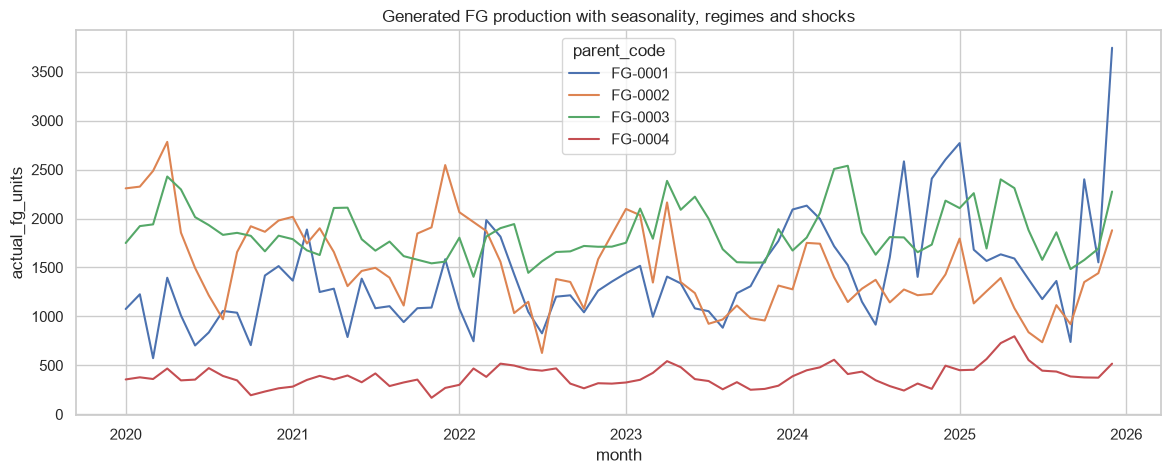

In [3]:
sample = production[production.parent_code.isin(production.parent_code.unique()[:4])]
fig, ax = plt.subplots(figsize=(14,5))
sns.lineplot(data=sample, x='month', y='actual_fg_units', hue='parent_code', ax=ax)
ax.set_title('Generated FG production with seasonality, regimes and shocks'); plt.show()

Spearman causal association: 0.8316612000771754


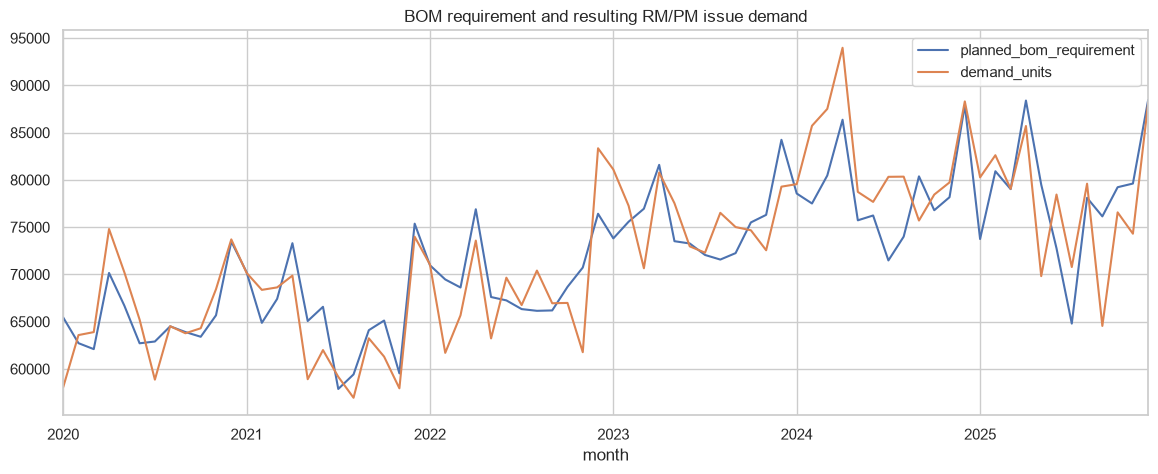

In [4]:
check = demand.groupby('month')[['planned_bom_requirement','demand_units']].sum()
print('Spearman causal association:', check.corr(method='spearman').iloc[0,1])
check.plot(figsize=(14,5), title='BOM requirement and resulting RM/PM issue demand'); plt.show()

Generator-only latent noise and shock magnitudes are not model features. Models receive lagged demand, declared calendar/plan signals and master data only, preventing direct target leakage.